In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
# Load the CSV 
df = pd.read_csv('/glade/u/home/klblack/SOARS_25/Chinook_subsistence.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Desired plotting/legend order
fish_columns = ['Fort Yukon', 'Tanana', 'Eagle', 'Galena']

# Clean numeric columns
for col in fish_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Keep relevant columns
df = df[['Year'] + fish_columns].dropna(subset=['Year'])

# Global font settings
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13
})



NameError: name 'legend' is not defined

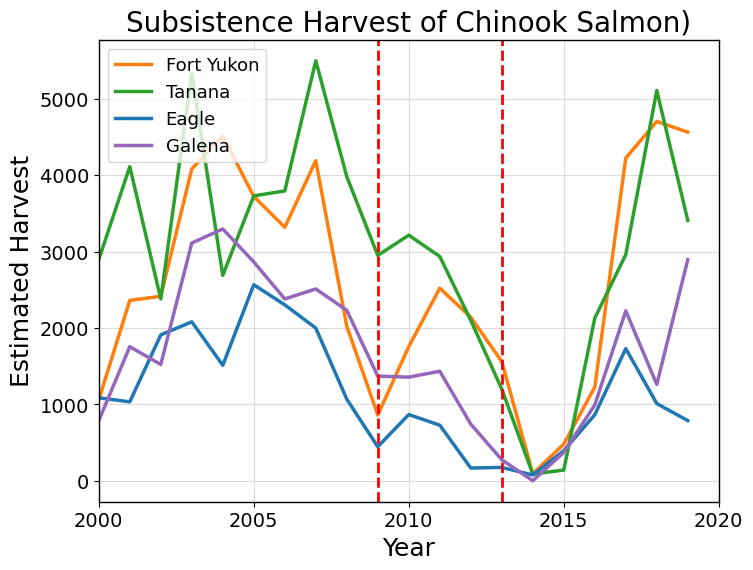

In [3]:
# Desired plotting/legend order
fish_columns = ['Fort Yukon', 'Tanana', 'Eagle', 'Galena']

colors = {
    'Fort Yukon': '#ff7f0e',
    'Tanana': '#2ca02c',
    'Eagle': '#1f77b4',
    'Galena': '#9467bd'
}

fig, ax = plt.subplots(figsize=(8, 6))

for col in fish_columns:
    ax.plot(
        df['Year'],
        df[col],
        color=colors[col],
        label=col,
        linewidth=2.5
    )

# Flood years, no labels
ax.axvline(x=2009, color='red', linestyle='--', linewidth=2)
ax.axvline(x=2013, color='red', linestyle='--', linewidth=2)

# Axis formatting
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.set_xlim(2000, 2020)

# Labels and title
ax.set_title('Subsistence Harvest of Chinook Salmon)')
ax.set_xlabel('Year')
ax.set_ylabel('Estimated Harvest')

# Match grid style
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.8, alpha=0.8)

# Black border around plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)

# Legend with grey border
ax.legend(loc='upper left', frameon=True)

legend.get_frame().set_edgecolor('grey')
legend.get_frame().set_linewidth(1)
legend.get_frame().set_alpha(1)

plt.tight_layout()

#plt.savefig('Chinook_subsistence.pdf', format='pdf', dpi=300)

plt.show()